# Final Model Comparison

This notebook compares the optimum/final results from the following models:

- Extra Trees
- Logistic Regression
- LightGBM
- TabNet
- TabPFN
- ANN
- XGBoost
- CatBoost

Each result CSV should contain:

`Model, Accuracy, Precision, Recall, F1_Score, ROC_AUC`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## 1. Upload final-result CSV files


In [2]:
from google.colab import files

uploaded = files.upload()


Saving ANN_final_result.csv to ANN_final_result.csv
Saving ExtraTrees_final_result.csv to ExtraTrees_final_result.csv
Saving final_catboost_model_metrics.csv to final_catboost_model_metrics.csv
Saving LightGBM_final_result.csv to LightGBM_final_result.csv
Saving LogisticRegression_final_result.csv to LogisticRegression_final_result.csv
Saving TabNet_final_result.csv to TabNet_final_result.csv
Saving TabPFN_final_result.csv to TabPFN_final_result.csv
Saving XGBoost_final_result.csv to XGBoost_final_result.csv


Upload these files (use the exact filenames below):

- `ExtraTrees_final_result.csv`
- `LogisticRegression_final_result.csv`
- `LightGBM_final_result.csv`
- `TabNet_final_result.csv`
- `TabPFN_final_result.csv`
- `ANN_final_result.csv`
- `XGBoost_final_result.csv`
- `CatBoost_final_result.csv`


## 2. Load all model results


In [3]:
extra_trees = pd.read_csv("ExtraTrees_final_result.csv")
logistic = pd.read_csv("LogisticRegression_final_result.csv")
lightgbm = pd.read_csv("LightGBM_final_result.csv")
tabnet = pd.read_csv("TabNet_final_result.csv")
tabpfn = pd.read_csv("TabPFN_final_result.csv")
ann = pd.read_csv("ANN_final_result.csv")
xgboost = pd.read_csv("XGBoost_final_result.csv")
catboost = pd.read_csv("final_catboost_model_metrics.csv")

print("All model results loaded successfully.")


All model results loaded successfully.


## 3. Combine optimum results


In [4]:
final_comparison = pd.concat(
    [
        extra_trees,
        logistic,
        lightgbm,
        tabnet,
        tabpfn,
        ann,
        xgboost,
        catboost
    ],
    ignore_index=True
)

display(final_comparison)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Extra Trees,0.858934,0.750000,0.428571,0.545455,0.847120
1,Logistic Regression,0.735110,0.399061,0.674603,0.501475,0.784889
2,LightGBM,0.809300,0.512287,0.716931,0.597574,0.863252
3,TabNet,0.827839,0.816182,0.846091,0.830868,0.903659
4,TabPFN,0.981278,0.984426,0.978013,0.981209,0.996175
5,ANN,0.839235,0.814340,0.878664,0.845280,0.911975
6,XGBoost,0.869353,0.861355,0.880293,0.870721,0.938606
7,CatBoost,0.821800,0.537200,0.706300,0.610300,0.861700


## 4. Round metric values


In [5]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

final_comparison[metric_columns] = (
    final_comparison[metric_columns].round(4)
)

display(final_comparison)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Extra Trees,0.8589,0.7500,0.4286,0.5455,0.8471
1,Logistic Regression,0.7351,0.3991,0.6746,0.5015,0.7849
2,LightGBM,0.8093,0.5123,0.7169,0.5976,0.8633
3,TabNet,0.8278,0.8162,0.8461,0.8309,0.9037
4,TabPFN,0.9813,0.9844,0.9780,0.9812,0.9962
5,ANN,0.8392,0.8143,0.8787,0.8453,0.9120
6,XGBoost,0.8694,0.8614,0.8803,0.8707,0.9386
7,CatBoost,0.8218,0.5372,0.7063,0.6103,0.8617


## 5. Sort models by ROC-AUC


In [6]:
comparison_sorted = final_comparison.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

display(comparison_sorted)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,TabPFN,0.9813,0.9844,0.9780,0.9812,0.9962
1,XGBoost,0.8694,0.8614,0.8803,0.8707,0.9386
2,ANN,0.8392,0.8143,0.8787,0.8453,0.9120
3,TabNet,0.8278,0.8162,0.8461,0.8309,0.9037
4,LightGBM,0.8093,0.5123,0.7169,0.5976,0.8633
5,CatBoost,0.8218,0.5372,0.7063,0.6103,0.8617
6,Extra Trees,0.8589,0.7500,0.4286,0.5455,0.8471
7,Logistic Regression,0.7351,0.3991,0.6746,0.5015,0.7849


## 6. Best overall model


In [7]:
best_model = comparison_sorted.iloc[0]

print("BEST PERFORMING MODEL")
print("---------------------")
print("Model     :", best_model["Model"])
print("Accuracy  :", best_model["Accuracy"])
print("Precision :", best_model["Precision"])
print("Recall    :", best_model["Recall"])
print("F1 Score  :", best_model["F1_Score"])
print("ROC-AUC   :", best_model["ROC_AUC"])


BEST PERFORMING MODEL
---------------------
Model     : TabPFN
Accuracy  : 0.9813
Precision : 0.9844
Recall    : 0.978
F1 Score  : 0.9812
ROC-AUC   : 0.9962


## 7. Accuracy comparison


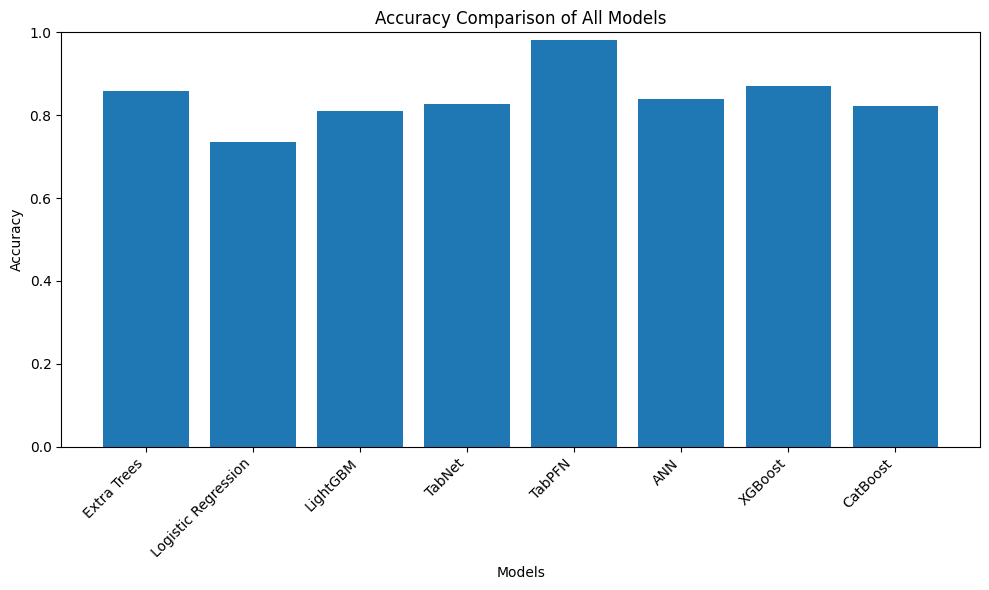

In [8]:
final_comparison["Model"] = final_comparison["Model"].astype(str)

plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["Accuracy"]
)

plt.title("Accuracy Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. F1-Score comparison


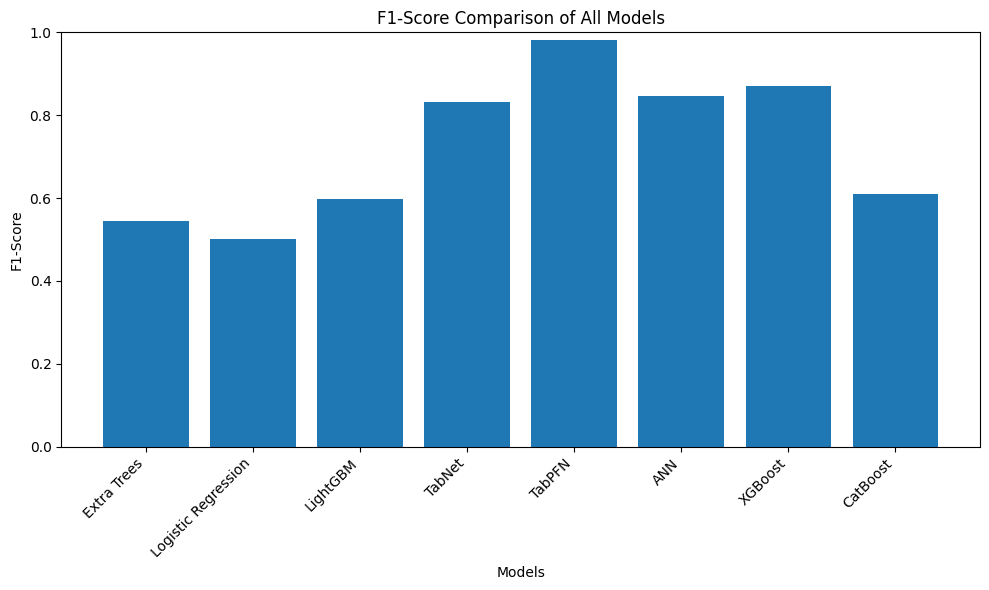

In [9]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["F1_Score"]
)

plt.title("F1-Score Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 9. ROC-AUC comparison


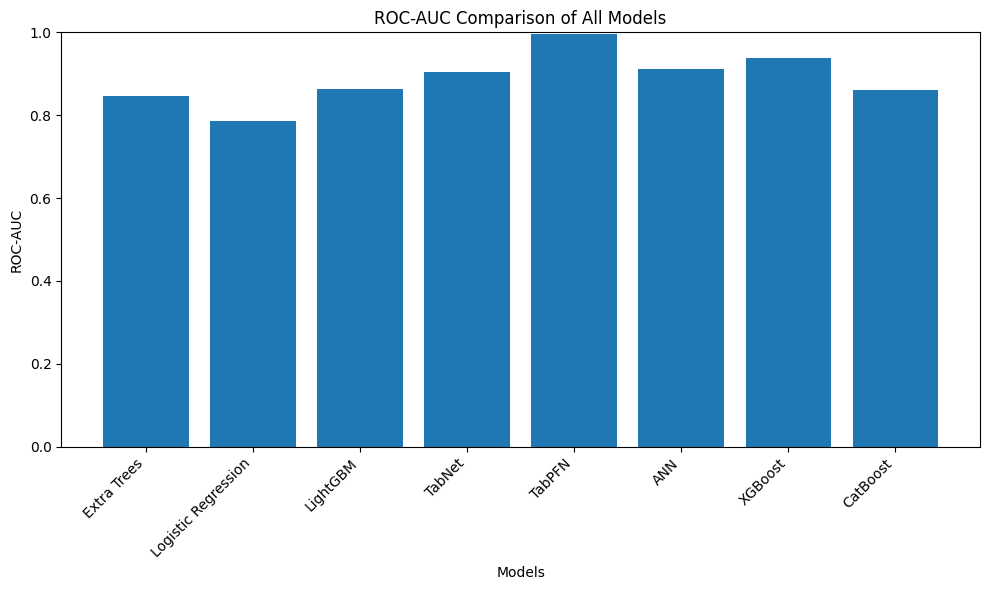

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["ROC_AUC"]
)

plt.title("ROC-AUC Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 10. Overall metrics comparison


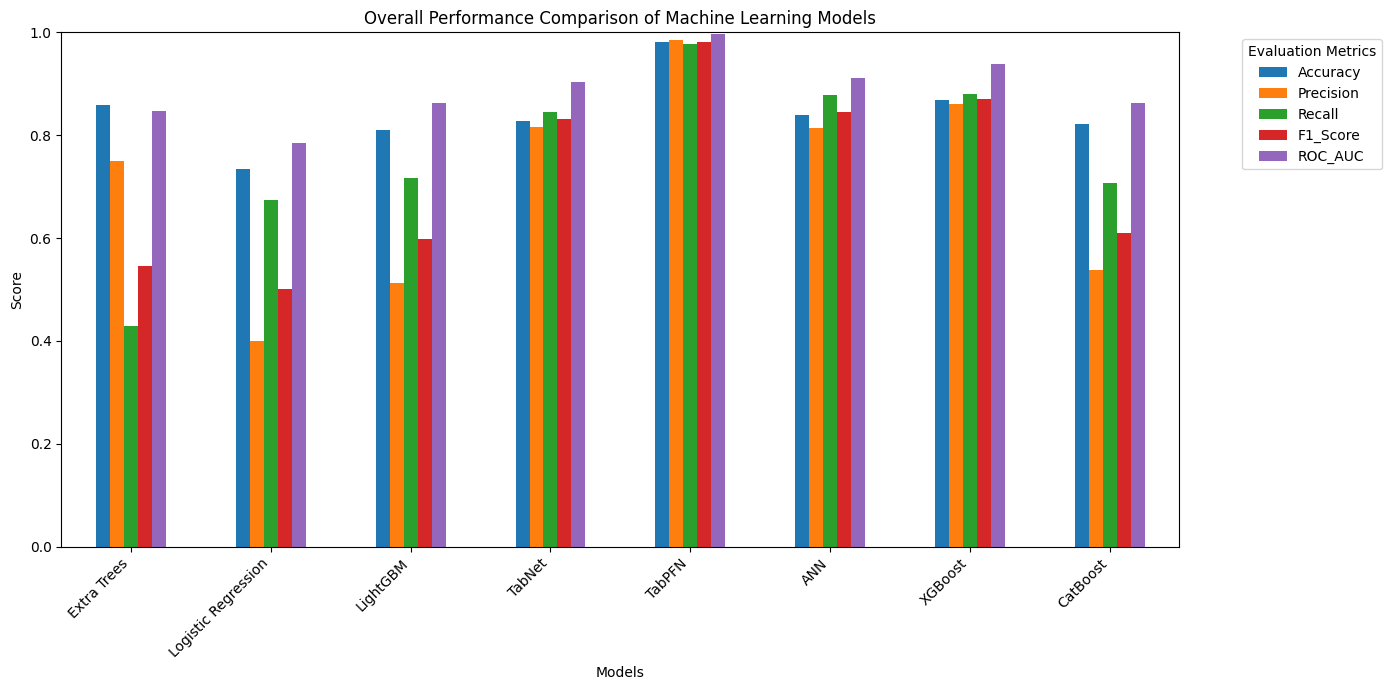

In [11]:
comparison_plot = final_comparison.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "ROC_AUC"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Overall Performance Comparison of Machine Learning Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Evaluation Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


## 11. Best model for each metric


In [12]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "ROC_AUC"
]

for metric in metrics:
    index = final_comparison[metric].idxmax()
    model = final_comparison.loc[index, "Model"]
    score = final_comparison.loc[index, metric]
    print(f"Best {metric}: {model} ({score:.4f})")


Best Accuracy: TabPFN (0.9813)
Best Precision: TabPFN (0.9844)
Best Recall: TabPFN (0.9780)
Best F1_Score: TabPFN (0.9812)
Best ROC_AUC: TabPFN (0.9962)


## 12. ROC-AUC ranking


In [13]:
import numpy as np

ranking = final_comparison.copy()

# Remove rows where ROC_AUC is missing or infinite
ranking = ranking.replace([np.inf, -np.inf], np.nan)
ranking = ranking.dropna(subset=["ROC_AUC"])

# Create ROC-AUC ranking
ranking["ROC_AUC_Rank"] = (
    ranking["ROC_AUC"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

# Sort by rank
ranking = ranking.sort_values("ROC_AUC_Rank")

display(ranking)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,ROC_AUC_Rank
4,TabPFN,0.9813,0.9844,0.9780,0.9812,0.9962,1
6,XGBoost,0.8694,0.8614,0.8803,0.8707,0.9386,2
5,ANN,0.8392,0.8143,0.8787,0.8453,0.9120,3
3,TabNet,0.8278,0.8162,0.8461,0.8309,0.9037,4
2,LightGBM,0.8093,0.5123,0.7169,0.5976,0.8633,5
7,CatBoost,0.8218,0.5372,0.7063,0.6103,0.8617,6
0,Extra Trees,0.8589,0.7500,0.4286,0.5455,0.8471,7
1,Logistic Regression,0.7351,0.3991,0.6746,0.5015,0.7849,8


## 13. Automatic conclusion


In [14]:
best = comparison_sorted.iloc[0]

print("MODEL COMPARISON CONCLUSION")
print("---------------------------")

print(
    f"{best['Model']} achieved the highest ROC-AUC "
    f"score of {best['ROC_AUC']:.4f}."
)

print(
    f"It achieved an accuracy of {best['Accuracy']:.4f}, "
    f"precision of {best['Precision']:.4f}, "
    f"recall of {best['Recall']:.4f}, and "
    f"F1-score of {best['F1_Score']:.4f}."
)

print(
    f"Therefore, {best['Model']} was selected as the optimum "
    "model based primarily on ROC-AUC and overall classification performance."
)


MODEL COMPARISON CONCLUSION
---------------------------
TabPFN achieved the highest ROC-AUC score of 0.9962.
It achieved an accuracy of 0.9813, precision of 0.9844, recall of 0.9780, and F1-score of 0.9812.
Therefore, TabPFN was selected as the optimum model based primarily on ROC-AUC and overall classification performance.


## 14. Save and download final comparison


In [15]:
comparison_sorted.to_csv(
    "Final_Model_Comparison.csv",
    index=False
)

print("Final comparison saved successfully.")

from google.colab import files
files.download("Final_Model_Comparison.csv")


Final comparison saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Viva Summary

Each individual model was trained and evaluated separately. The optimum/final result from each model is combined here. The models are compared using Accuracy, Precision, Recall, F1-Score and ROC-AUC. The notebook ranks models by ROC-AUC and reports the strongest model while also showing which model performs best for each individual metric.
